In [1]:
%matplotlib widget
import hyperspy.api as hs
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

outputpath='/home-local/ratel-ra/Documents/ePDF_project/TEM_data/200kV/JEM_200/mtf/'

## OneView camera

In [2]:
path = '/home-local/ratel-ra/Documents/ePDF_project/TEM_data/200kV/JEM_200/SESSION_III/mtf/oneview'
files = glob.glob(path + '/*.dm4')
for file in files: 
    s = hs.load(file)
    fname = file.split('/')[-1]
    print(f'{fname}: shape = {s.data.shape}')

20kX_OneView_200kV_2432.dm4: shape = (4096, 4096)
20kX_OneView_200kV_2433.dm4: shape = (2048, 2048)


**Resolution 4096x4096**

On essaie d'appliquer un masque pour ne travailler que sur un seul edge. Le masque est tracé à l'aide de pyFAI-drawmask

[INFO] Edge detected: angle=17.95°, rho=-1336.0 px, x_edge≈1986.8 px
[INFO] Asymmetric ROI: dark side=100.0 px, bright side=19.1 px (available: left=1967.0, right=19.1)
[INFO] erf fit: x0=-0.81 px, sigma=1.923 px
MTF50: 0.202 f_Nyq  (0.007 µm⁻¹)
MTF20: 0.303 f_Nyq  (0.010 µm⁻¹)
Signal patch (background, eroded 5px): 23067 pixels, Noise patch (beamstop, eroded 5px): 460990 pixels


/home-local/ratel-ra/Documents/ePDF_project/Code/ePDFsuite/src/epdfsuite/utilities.py:536: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(mask_noise_disp, levels=[0.5], colors='red', linewidths=2, linestyles='-', label='Noise (beamstop)')
/home-local/ratel-ra/Documents/ePDF_project/Code/ePDFsuite/src/epdfsuite/utilities.py:540: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(mask_signal_disp, levels=[0.5], colors='blue', linewidths=1, linestyles='--', label='Signal (background)')


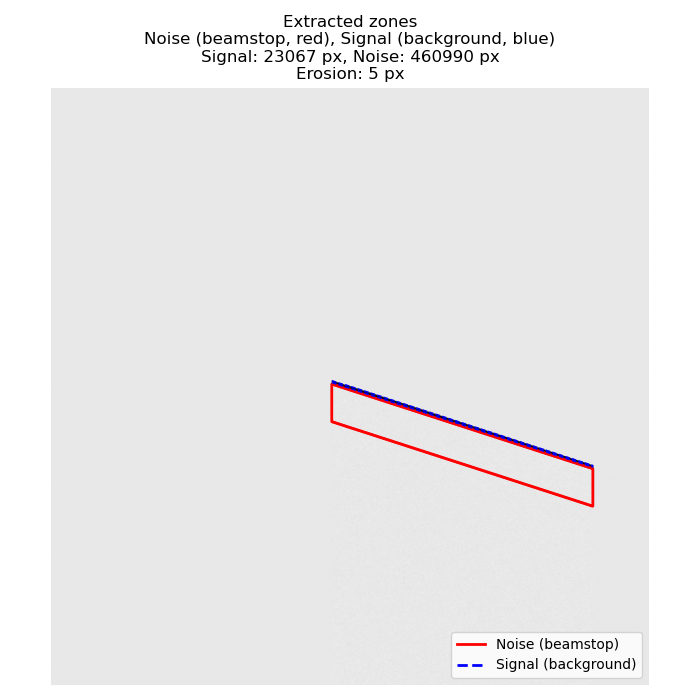

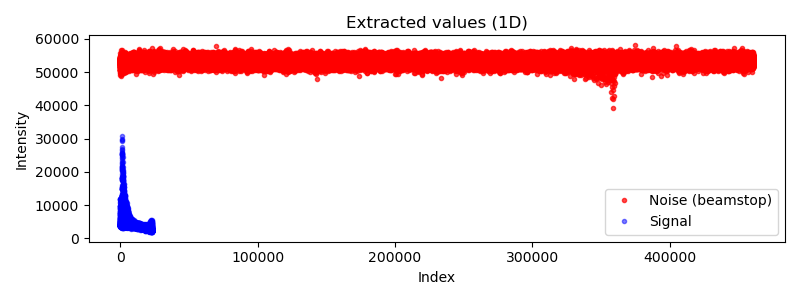

Estimated Wiener epsilon (noise/signal ratio): 0.0751


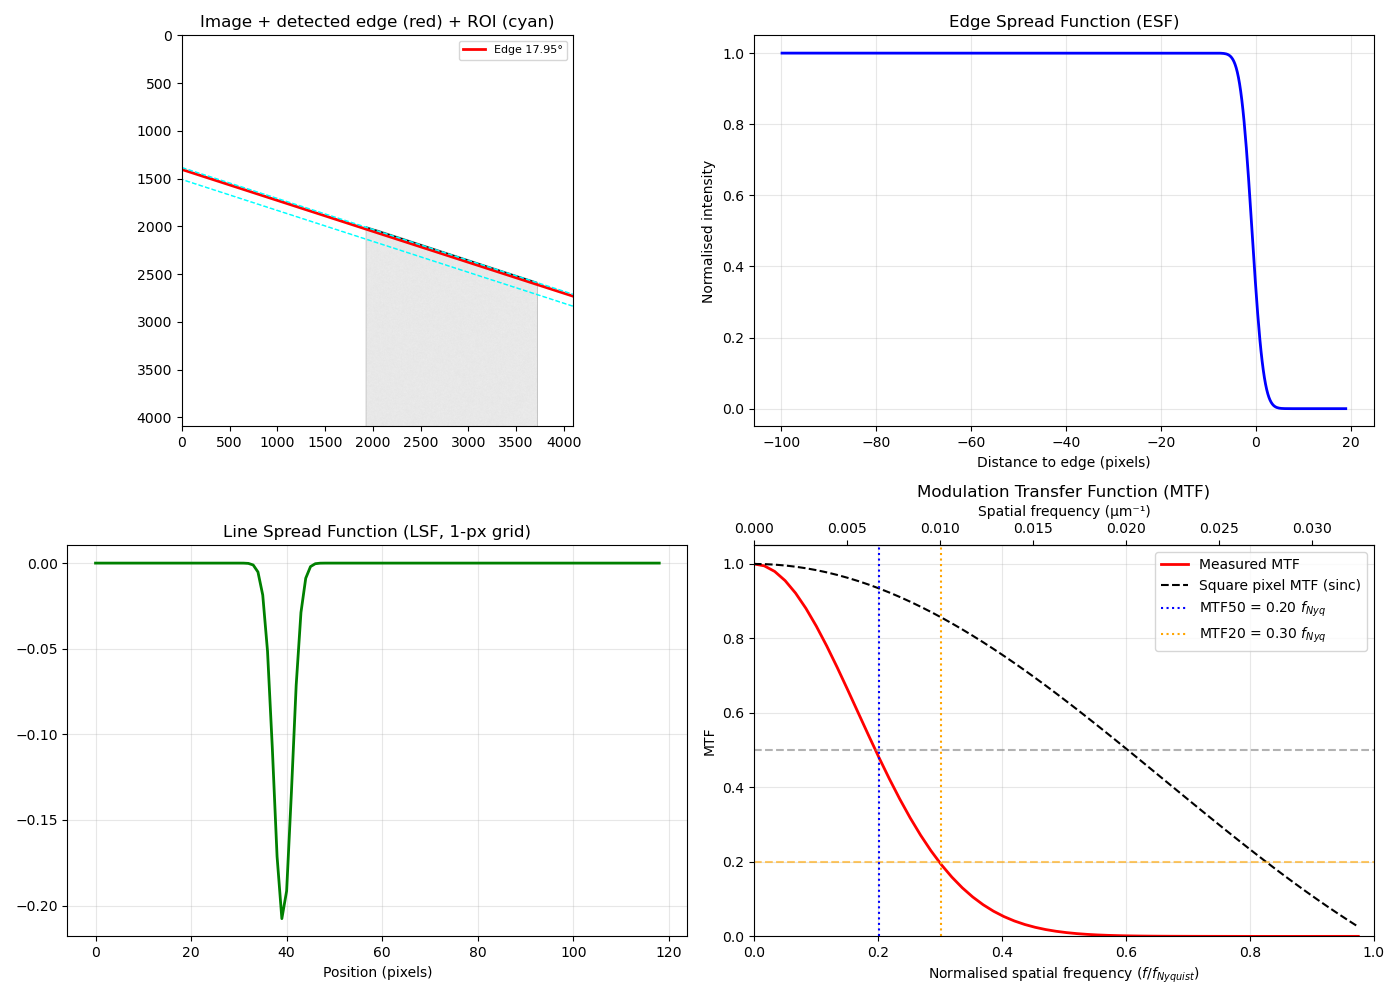

MTF saved: /home-local/ratel-ra/Documents/ePDF_project/TEM_data/200kV/JEM_200/mtf//oneview_4k_slanted.mtf


In [3]:
from epdfsuite.utilities import compute_mtf_slanted_edge
outputfile=outputpath+'/oneview_4k_slanted.mtf'
maskfile = '/home-local/ratel-ra/Documents/ePDF_project/TEM_data/200kV/JEM_200/SESSION_III/mtf/oneview/mask_oneview_4k.edf'
freq, mtf = compute_mtf_slanted_edge(
    files[0],
    mask=maskfile,
    roi_half_width=100,
    smooth_sigma=0.0,
    outputfile=outputfile)    
   


**Resolution 2048x2048**


In [4]:
from epdfsuite.calibration import perform_geometric_calibration
cif_file = "/home-local/ratel-ra/Documents/CIF_database/Au_fixed.cif"

#perform_geometric_calibration(
#    image_file=files[1],
#    cif_file = cif_file)

[INFO] Edge detected: angle=17.95°, rho=-670.0 px, x_edge≈986.9 px
[INFO] Asymmetric ROI: dark side=100.0 px, bright side=10.6 px (available: left=984.0, right=10.6)
[INFO] erf fit: x0=1.77 px, sigma=1.036 px
MTF50: 0.360 f_Nyq  (0.012 µm⁻¹)
MTF20: 0.559 f_Nyq  (0.019 µm⁻¹)
Signal patch (background, eroded 5px): 5282 pixels, Noise patch (beamstop, eroded 5px): 232814 pixels


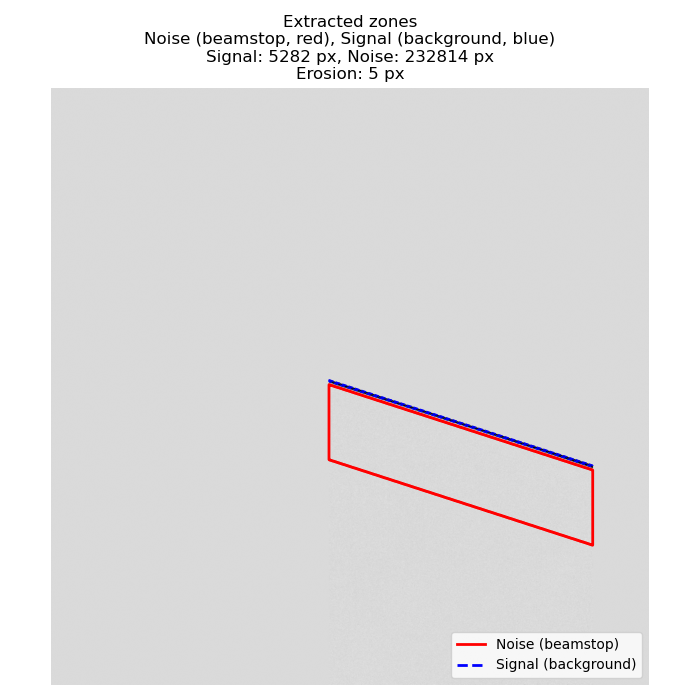

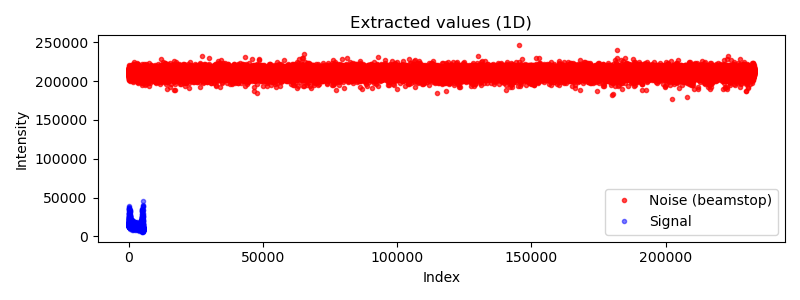

Estimated Wiener epsilon (noise/signal ratio): 0.1042


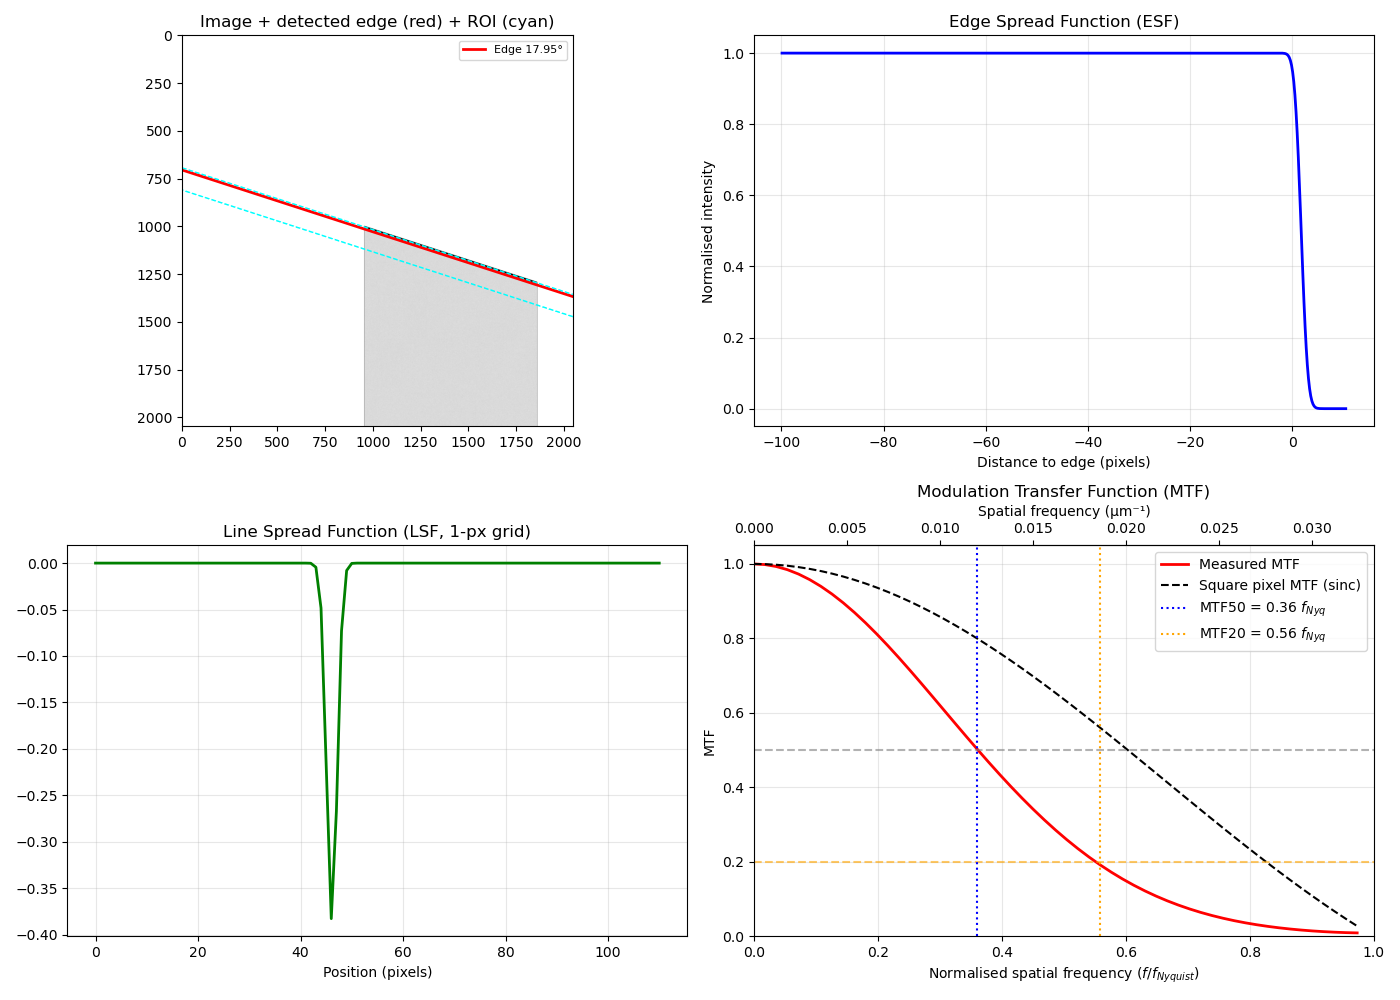

MTF saved: /home-local/ratel-ra/Documents/ePDF_project/TEM_data/200kV/JEM_200/mtf//oneview_2k_slanted.mtf


In [5]:
from epdfsuite.utilities import compute_mtf_slanted_edge
outputfile=outputpath+'/oneview_2k_slanted.mtf'
maskfile = '/home-local/ratel-ra/Documents/ePDF_project/TEM_data/200kV/JEM_200/SESSION_III/mtf/oneview/mask_oneview_2k.edf'
freq, mtf = compute_mtf_slanted_edge(
    files[1],
    mask=maskfile,
    roi_half_width=100,
    outputfile=outputfile) 

**Metro camera**

In [6]:
path = '/home-local/ratel-ra/Documents/ePDF_project/TEM_data/200kV/JEM_200/SESSION_III/mtf/metro'
files = glob.glob(path + '/*.dm4')
for file in files: 
    s = hs.load(file)
    fname = file.split('/')[-1]
    print(f'{fname}: shape = {s.data.shape}')
    

20kX_Metro_200kV_2422.dm4: shape = (2048, 2048)
20kX_Metro_200kV_2423.dm4: shape = (2048, 2048)
20kX_Metro_200kV_2424.dm4: shape = (2048, 2048)


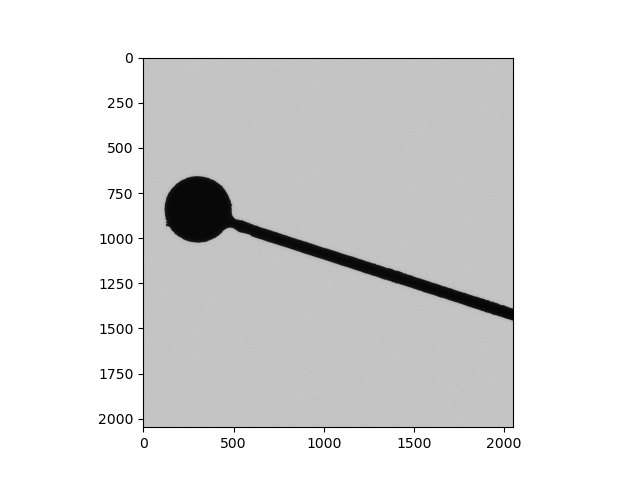

In [7]:
from epdfsuite.calibration import perform_geometric_calibration
cif_file = "/home-local/ratel-ra/Documents/CIF_database/Au_fixed.cif"

#perform_geometric_calibration(
#    image_file=files[2],
#    cif_file = cif_file)

plt.figure()
s=hs.load(files[2])
plt.imshow(s.data, cmap='gray')

[INFO] Edge detected: angle=17.85°, rho=-697.0 px, x_edge≈906.0 px
[INFO] Asymmetric ROI: dark side=55.4 px, bright side=100.0 px (available: left=55.4, right=1324.5)
[INFO] erf fit: x0=0.29 px, sigma=1.626 px
MTF50: 0.231 f_Nyq  (0.023 µm⁻¹)
MTF20: 0.346 f_Nyq  (0.035 µm⁻¹)
Signal patch (background, eroded 5px): 389431 pixels, Noise patch (beamstop, eroded 5px): 77534 pixels


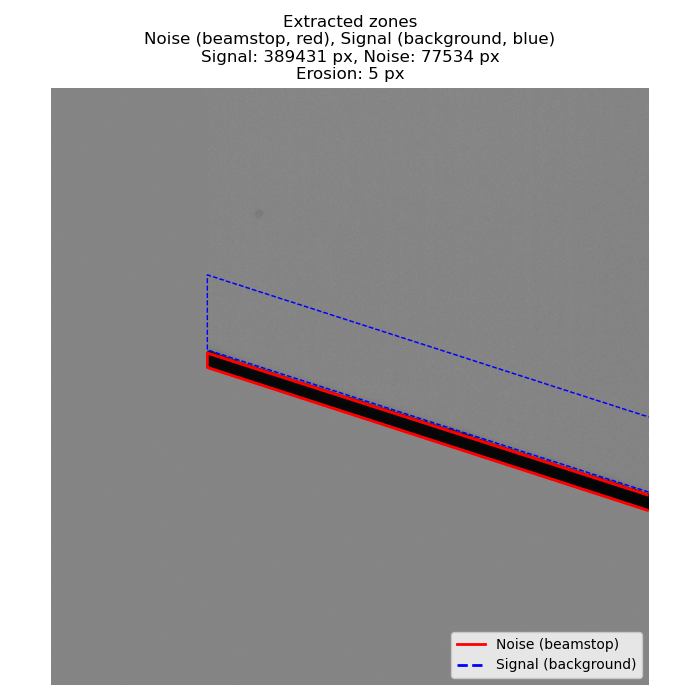

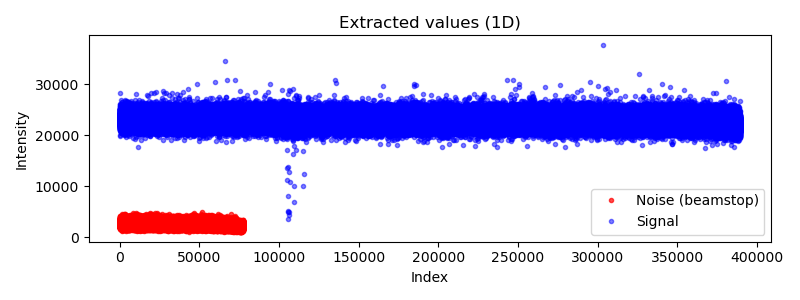

Estimated Wiener epsilon (noise/signal ratio): 0.0115


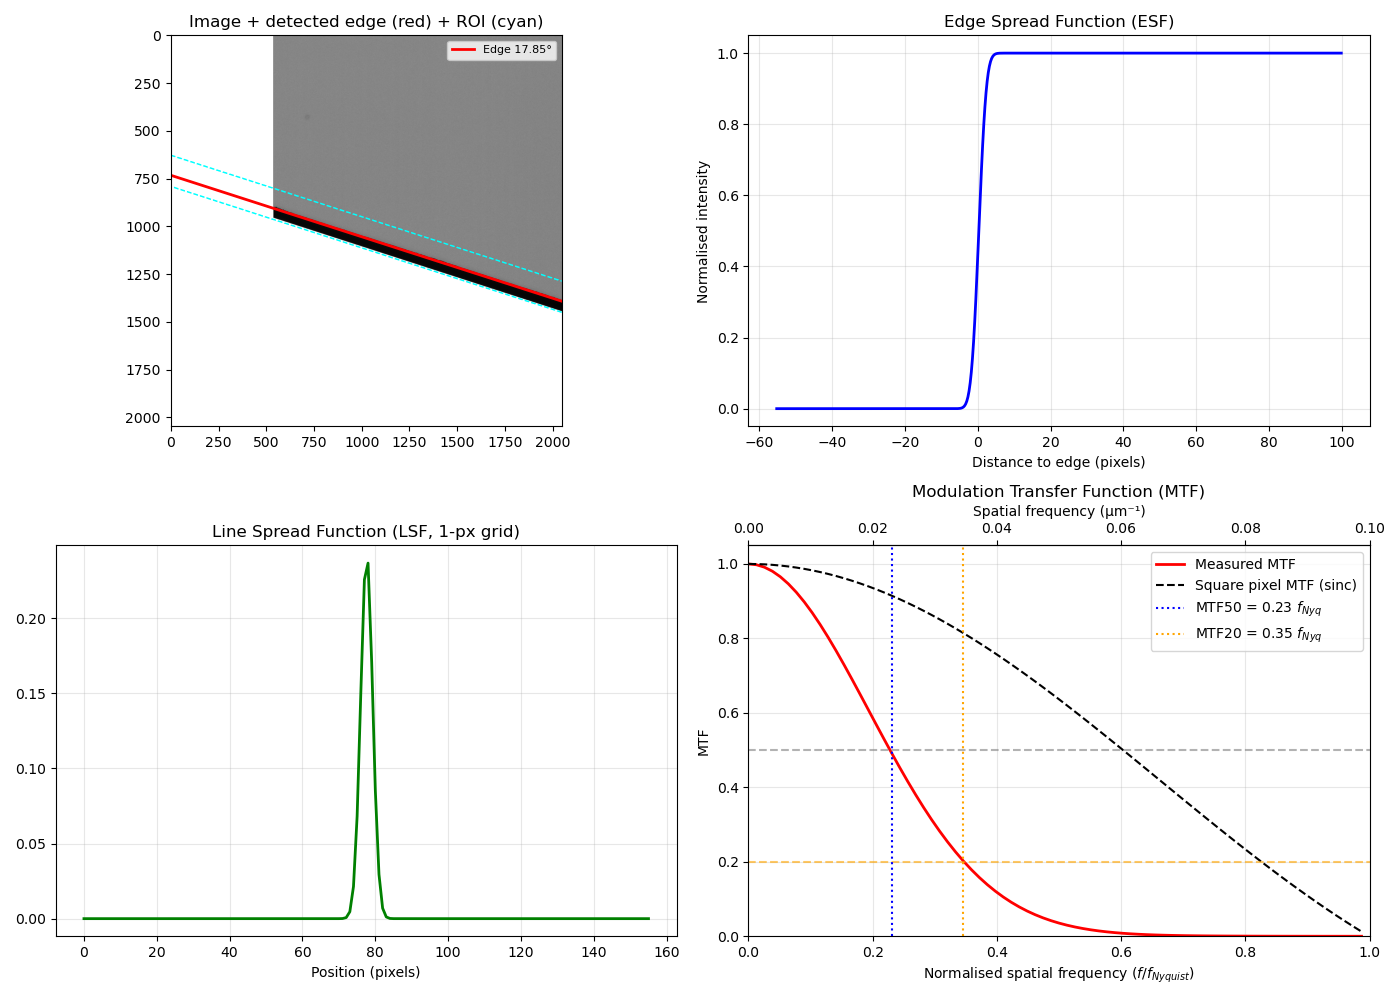

MTF saved: /home-local/ratel-ra/Documents/ePDF_project/TEM_data/200kV/JEM_200/mtf//metro_slanted.mtf


In [8]:
from epdfsuite.utilities import compute_mtf_slanted_edge
maskfile = '/home-local/ratel-ra/Documents/ePDF_project/TEM_data/200kV/JEM_200/SESSION_III/mtf/metro/mask_metro.edf'
outputfile=outputpath+'/metro_slanted.mtf'
freq, mtf = compute_mtf_slanted_edge(
    files[1],
    mask=maskfile,
    roi_half_width=100,
    outputfile=outputfile) 

## Comparaison des MTF

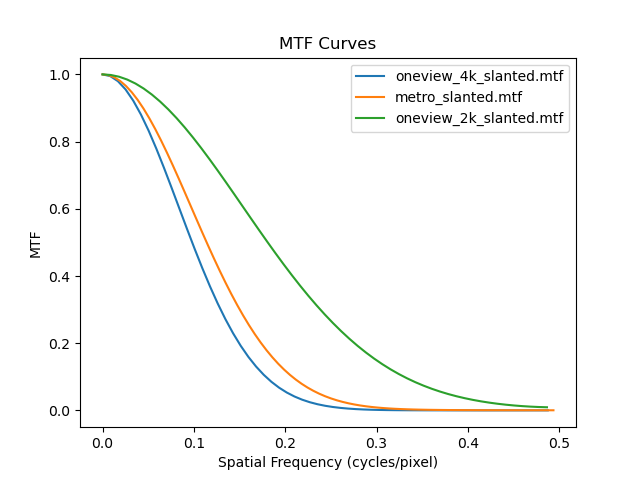

In [9]:
mtfpath = '/home-local/ratel-ra/Documents/ePDF_project/TEM_data/200kV/JEM_200/mtf'
mtf_files= glob.glob(mtfpath + '/*_slanted*.mtf')
plt.figure()
for file in mtf_files:
    data = np.loadtxt(file, comments='#')
    freq = data[:, 0]
    mtf_values = data[:, 1]
    fname = file.split('/')[-1]
    plt.plot(freq, mtf_values, label=fname)
plt.xlabel('Spatial Frequency (cycles/pixel)')
plt.ylabel('MTF')
plt.title('MTF Curves')
plt.legend()

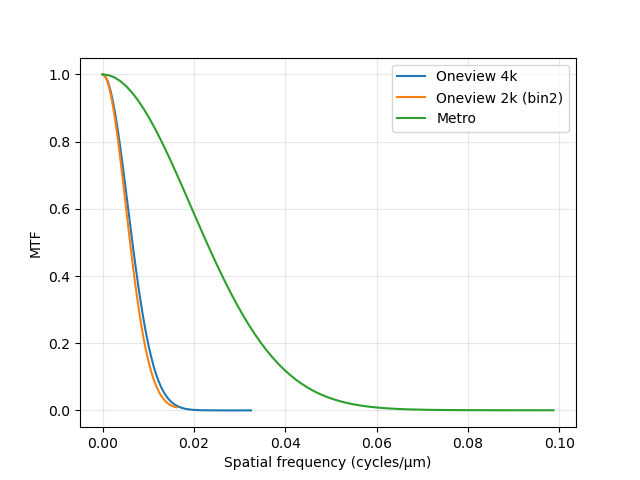

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Charger les MTF
f_4k,  mtf_4k,epsilon_4k  = np.loadtxt(mtfpath+'/oneview_4k_slanted.mtf',  comments='#').T
f_2k,  mtf_2k,epsilon_2k  = np.loadtxt(mtfpath+'/oneview_2k_slanted.mtf',  comments='#').T
f_metro, mtf_metro,epsilon_metro = np.loadtxt(mtfpath+'/metro_slanted.mtf',    comments='#').T

px_4k   = 15   # mm → ou µm selon ton unité
px_2k   = 30  # binning 2
px_metro = 5    # taille pixel Metro

plt.figure()
plt.plot(f_4k   / px_4k,    mtf_4k,   label='Oneview 4k')
plt.plot(f_2k   / px_2k,    mtf_2k,   label='Oneview 2k (bin2)')
plt.plot(f_metro / px_metro, mtf_metro, label='Metro')
plt.xlabel('Spatial frequency (cycles/µm)')
plt.ylabel('MTF')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

La caméra Metro est en mode intégration plutot qu'en mode comptage. C'est pour cette raison qu'on n'observe pas de plateau dans le MTF.